<a href="https://colab.research.google.com/github/sanchi23002/COMPUTER_VISION_WITH_OPENCV_AND_DEEP_LEARNING/blob/main/masking_in_image.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt


ALL THE IMAGES ARE FROM DATA FILE , WHICH IS IN ML IMPORTANT THING FOLDER , INSIDE COMPUTER VISION WITH PYTHON FILE

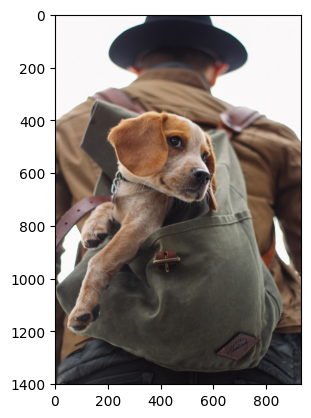

In [ ]:
from PIL import Image
img = Image.open('dog_backpack.jpg')
pic1 = np.asarray(img)# it searches the memory for the data, if exist then use same memory , so save memory
plt.imshow(pic1)

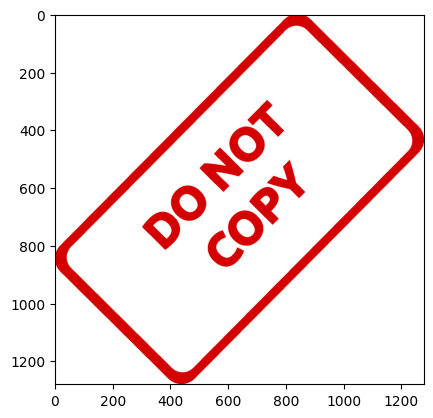

In [ ]:
img2 = cv2.imread('watermark_no_copy.png')
pic2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
plt.imshow(pic2)

In [ ]:
pic2.dtype

dtype('uint8')

In [ ]:
rows , columns , channels = pic2.shape
print(rows)
print(columns)
print(channels)

1280
1277
3


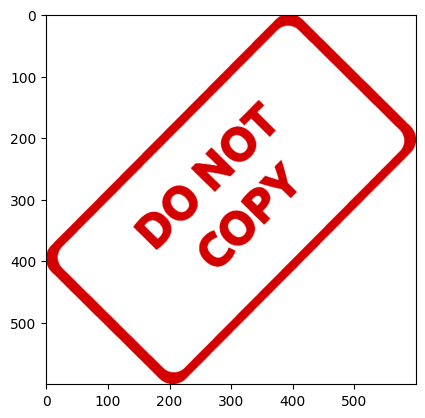

In [ ]:
pic_2 = cv2.resize(pic2, (600,600)) # don't try to use np.resize , because it can't understand the pixel , it destroy the image
plt.imshow(pic_2)

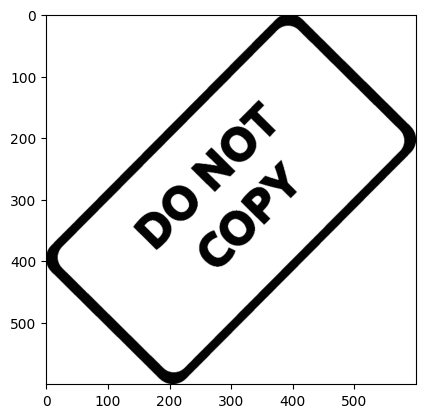

In [ ]:
gray_pic = cv2.cvtColor(pic_2, cv2.COLOR_RGB2GRAY) # WITHOUT THIS LINE IF YOU TRY TO DO CMAP GRAY , THE CODE WILL COMPLETELY IGNORE IT,AS IT IS RGBIMAGE FORTHE CODE
plt.imshow(gray_pic, cmap ='gray')

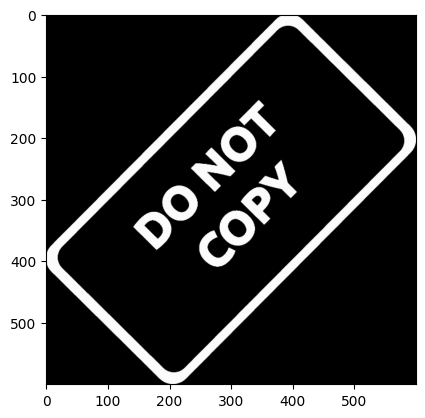

In [ ]:
mask_inv = cv2.bitwise_not(gray_pic) # NEW VALUE OF EVERY BIT IS 255-original value
plt.imshow(mask_inv, cmap = 'gray')

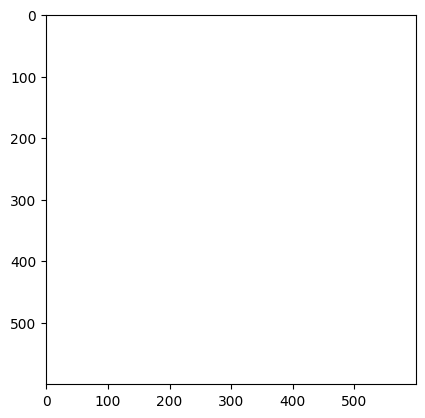

In [ ]:
white_background = np.full(pic_2.shape,255, dtype=np.uint8)
plt.imshow(white_background)

(600, 600, 3)


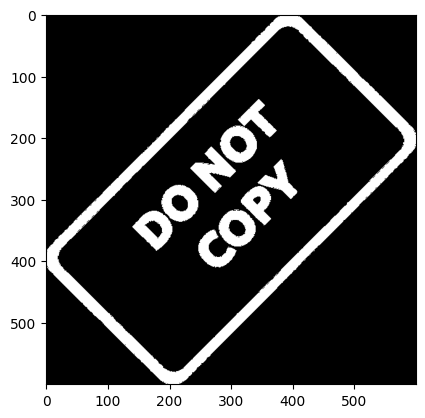

In [ ]:
bk = cv2.bitwise_or(white_background, white_background, mask = mask_inv)
plt.imshow(bk)
print(bk.shape)

(600, 600, 3)


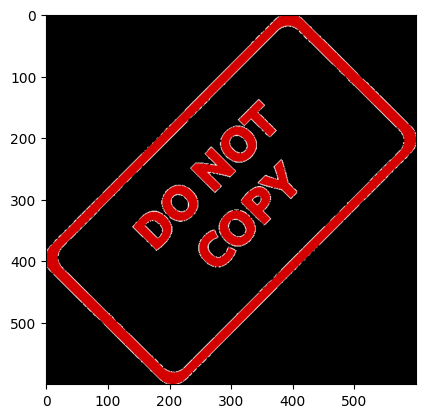

In [ ]:
fg = cv2.bitwise_or(pic_2, pic_2, mask = mask_inv)
plt.imshow(fg)
print(fg.shape)

In [ ]:
pic1.shape

(1401, 934, 3)

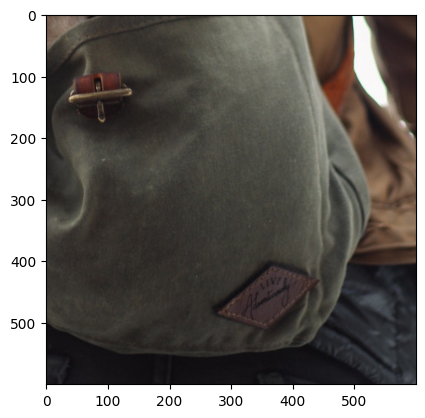

In [ ]:
y_offset = 1401-600
x_offset = 934-600
roi = pic1[y_offset:1401,x_offset:934,:]
plt.imshow(roi)

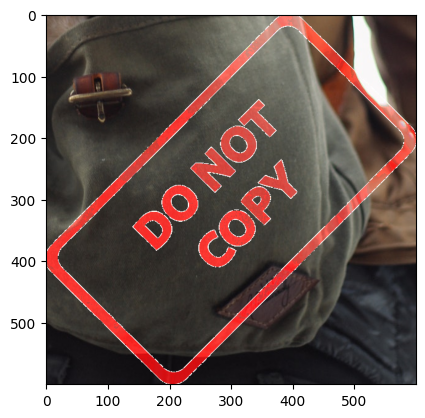

In [ ]:
final_roi = cv2.bitwise_or(fg, roi)
plt.imshow(final_roi)

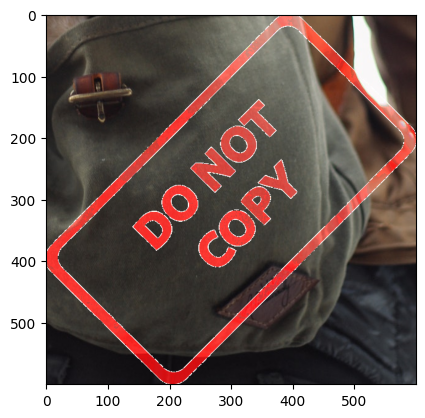

In [ ]:
final_roi = cv2.bitwise_or(roi , fg)
plt.imshow(final_roi)

In [ ]:
new_pic1 = pic1.copy()

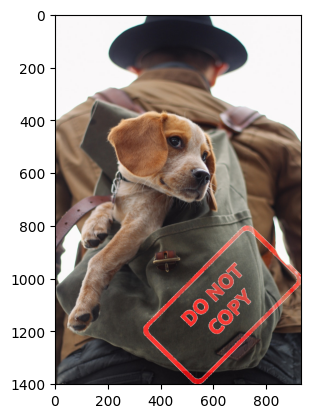

In [ ]:
new_pic1[y_offset:1401,x_offset:934,:] = final_roi
plt.imshow(new_pic1)